### Import dependencices

In [7]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

from typing import Literal, Annotated, List, Any
from IPython.display import Image, display
from jinja2 import Template
from operator import add
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage
from langchain_openai import ChatOpenAI
import openai
import pandas as pd
from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

### Single node Graph

In [138]:
# langgraph state e.g native python class or pydantic class 

class State(BaseModel):
    message: str
    answer: str = ""
    vibe: str = ""

In [139]:
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": f"{state.message} {state.vibe}"
    }

In [140]:

workflow = StateGraph(State)
workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibes_to_query", END)
# compile the graph
graph = workflow.compile()

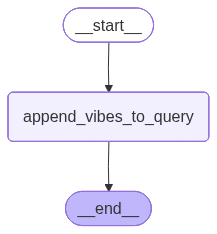

In [141]:
# when the graph exits we get a dicgtionary that is represnetation of the state of the graph at the end of execution
display(Image(graph.get_graph().draw_mermaid_png()))

In [142]:
initial_state = {
    "message": "Give me some vibes",
    "vibe": "I'm feeling like a badass today!"
}
result = graph.invoke(initial_state)
print(result["answer"])

Give me some vibes I'm feeling like a badass today!


In [143]:
# if i provide the answer 

initial_state = {
    "message": "Give me some vibes",
    "answer": "abc",
    "vibe": "I'm feeling like a badass today!"
}
result = graph.invoke(initial_state)
print(result)

# answer is overwritten .... 


{'message': 'Give me some vibes', 'answer': "Give me some vibes I'm feeling like a badass today!", 'vibe': "I'm feeling like a badass today!"}


### Conditional Graph

In [144]:
class State(BaseModel):
    message: str
    answer: str = ""

In [145]:
def append_vibes_to_query(state: State) -> dict:
    return {
        "answer": state.message,
        # the message is modifiable as exemplified here
        "message": f"message is {state.message}"
    }

In [146]:
def append_vibe1(state: State) -> dict:
    vibe = "im feeling like a badass today!"
    return {
        "answer": f"{state.message} {vibe}"
    }

def append_vibe2(state: State) -> dict:
    vibe = "im feeling like a boss today!"
    return {
        "answer": f"{state.message} {vibe}"
    }

def append_vibe3(state: State) -> dict:
    vibe = "im feeling like a legend today!"
    return {
        "answer": f"{state.message} {vibe}"
    }

In [147]:
## This type of output will allow langgraph to properly visualize the graph
## these strings are actually mapping to a node name (not a function name)
import random

def router(state: State) -> Literal["append_vibe1", "append_vibe2", "append_vibe3"]:
    # some logic to determine which vibe to append
    vibes = ["append_vibe1", "append_vibe2", "append_vibe3"]
    vibe_path = random.choice(vibes)
    return vibe_path


In [148]:

workflow = StateGraph(State)
# workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe1", append_vibe1)
workflow.add_node("append_vibe2", append_vibe2)
workflow.add_node("append_vibe3", append_vibe3)

workflow.add_conditional_edges(
    START, 
    router,
    {
        "append_vibe1": "append_vibe1",
        "append_vibe2": "append_vibe2",
        "append_vibe3": "append_vibe3"
    }
)

# workflow.add_edge(START, "append_vibes_to_query")
## need to always exit the graph
workflow.add_edge("append_vibe1", END)
workflow.add_edge("append_vibe2", END)
workflow.add_edge("append_vibe3", END)

# compile the graph
graph = workflow.compile()


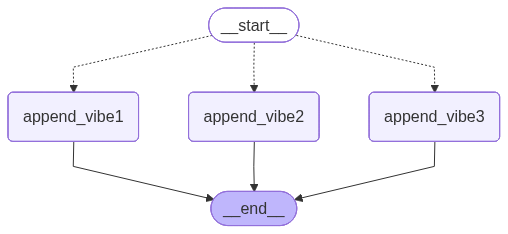

In [149]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [150]:
initial_state = {
    "message": "Give me some vibes",
}
result = graph.invoke(initial_state)
print(result["message"], result["answer"])

Give me some vibes Give me some vibes im feeling like a boss today!


### Exploring LangChain Tool Calling...

In [152]:
@tool # decorate it so langchain can use it....
def dummy_tool(a: str, b: str) -> str:
  # this is a doc string so that the llm knows what the tool is doing/what it can do....
  # the llm will choose how to fill the params based on the args description... + arg type hints
  """Concatenate two strings.

  Args:
    a: The first string to concatenate
    b: The second string to concatenate

  Returns:
    A string of the two strings concatenated.
  """
  return f"Hello {a} and {b}"

# the result of the tool is injected into message history

In [153]:
llm = ChatOpenAI(
    model="gpt-5.4-mini", 
    reasoning_effort = "none",
    use_responses_api = True # we cannot use completions api ... (indicates augmented llm) 
)

llm_with_tools = llm.bind_tools(
    [dummy_tool],
    tool_choice="auto" # auto means llm can suggest or not suggest the tool (any forces the llm to suggest any of the tools provided in the toolset)
)

response = llm_with_tools.invoke("Use dummy tool to concatenate two random words")


In [154]:
response.tool_calls # this is how the model used the tool...

[{'name': 'dummy_tool',
  'args': {'a': 'sunset', 'b': 'lantern'},
  'id': 'call_ZIjfkoZSlWlJRzY4OGECtFss',
  'type': 'tool_call'}]

In [155]:
response.usage_metadata
# no reasoning tokens because reasoning effort is none....

{'input_tokens': 84,
 'output_tokens': 25,
 'total_tokens': 109,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 0}}

### Agent Graph (simple not a loop agent)

In [159]:
@tool
def append_vibes(query: str, vibe: str) -> str:
  """Takes in a query and a vibe and returns a string with the query and vibe appended.

  Args:
    query: The query to append the vibe to.
    vibe: The vibe to append to the query.

  Returns:
    A string with the query and vibe appended.
  """
  return f"{query} {vibe}"

In [160]:
class State(BaseModel):
    query: str
    messages: Annotated[List[Any], add] = [] # if we dont add the add reducer every iteration will overwrite the message instead of appending to the message history
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

In [ ]:
def agent_node(state: State) -> dict: # agent node always gets state object
    # jinja template for the prompt that we will send to the llm
    prompt_template = """
        You are an assistant that is generating vibes for a user.

        ## Instructions

        - You need to use the tools to add vibes to the user's query.
        - Add a random vibe to the user's query.

        ### User Query
        {{ query }}
    """
    
    template = Template(prompt_template) ## create a jinja template object
    prompt = template.render(query=state.query) ## render the template with the query from the
    llm = ChatOpenAI(
        model="gpt-5.4-mini", 
        reasoning_effort = "none",
        use_responses_api = True # we cannot use completions api ... (indicates augmented llm) 
    )

    llm_with_tools = llm.bind_tools(
        [append_vibes],
        tool_choice="auto" # auto means llm can suggest or not suggest the tool (any forces the llm to suggest any of the tools provided in the toolset)
    )

    response = llm_with_tools.invoke([
        SystemMessage(prompt) ## open ais abstractioon on creating a message object from a string (llm only takes in messages objects as input so we need to convert our prompt into a message object)
    ])
    
    # response.tool_calls.... 
    return {
        "messages": [response]
    }

In [162]:
def tool_router(state: State) -> str:
    if len(state.messages[-1].tool_calls) > 0: # if the model called a tool we want to go to the agent node again to see if it wants to call another tool
        return "tools"
    else:
        return "end"

In [178]:
initial_state= {
    "query": "Give me some vibes",
}

result = graph.invoke(initial_state)
print(result)

{'query': 'Give me some vibes', 'messages': [AIMessage(content=[{'arguments': '{"query":"Give me some vibes","vibe":"with a dreamy, neon-lit, late-night energy"}', 'call_id': 'call_ZHrMHK8CfTtIfkSE7gG4GuoY', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_0dffaa6b732eb9a5006a4f452f63d8819bad7bbe98965a1483', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0dffaa6b732eb9a5006a4f452ebc3c819ba33ff71c88d17b6c', 'created_at': 1783579950.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_0dffaa6b732eb9a5006a4f452ebc3c819ba33ff71c88d17b6c', tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes', 'vibe': 'with a dreamy, neon-lit, late-night energy'}, 'id': 'call_ZHrMHK8CfTtIfkSE7gG4GuoY', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 149, 'output_tok

In [181]:
result
for msg in result["messages"]:
    print(type(msg).__name__, ":", msg.content)

AIMessage : [{'arguments': '{"query":"Give me some vibes","vibe":"with a dreamy, neon-lit, late-night energy"}', 'call_id': 'call_ZHrMHK8CfTtIfkSE7gG4GuoY', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_0dffaa6b732eb9a5006a4f452f63d8819bad7bbe98965a1483', 'status': 'completed'}]
ToolMessage : Give me some vibes with a dreamy, neon-lit, late-night energy


### Agent Graph With Loopback from Tools (ReAct Agent)

In [13]:
@tool
def append_vibes(query: str, vibe: str) -> str:
  """Takes in a query and a vibe and returns a string with the query and vibe appended.

  Args:
    query: The query to append the vibe to.
    vibe: The vibe to append to the query.

  Returns:
    A string with the query and vibe appended.
  """
  return f"{query} {vibe}"

class FinalResponse(BaseModel):
    answer: str

class State(BaseModel):
    messages: Annotated[List[Any], add] = [] # if we dont add the add reducer every iteration will overwrite the message instead of appending to the message history
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    
def agent_node(state: State) -> dict: # agent node always gets state object
    # jinja template for the prompt that we will send to the llm
    # teh agent needs to see what has been done ...
    prompt_template = """
        You are an assistant that is generating vibes for a user.

        ## Instructions

        - You need to use the tools to add vibes to the user's query.
        - Add a random vibe to the user's query.
        - You must return a tool call in the first interaction
    """
    
    template = Template(prompt_template) ## create a jinja template object
    prompt = template.render() ## render the template with the query from the
    llm = ChatOpenAI(
        model="gpt-5.4-mini", 
        reasoning_effort = "none",
        use_responses_api = True # we cannot use completions api ... (indicates augmented llm) 
    )

    # tools can be functions or pydantic models
    llm_with_tools = llm.bind_tools(
        [append_vibes, FinalResponse], # we can also return a final response from the model instead of going through the graph again (this is useful for when we want to return a final answer to the user instead of going through the graph again)
        tool_choice="auto" # auto means llm can suggest or not suggest the tool (any forces the llm to suggest any of the tools provided in the toolset)
    )

    response = llm_with_tools.invoke([
        SystemMessage(prompt), ## open ais abstractioon on creating a message object from a string (llm only takes in messages objects as input so we need to convert our prompt into a message object),
        *state.messages ## we also want to pass in the message history so that the model can see what has been done in previous iterations
    ])
    
    final_answer = False
    answer = ""
    
    if(len(response.tool_calls) > 0):
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")
                
    # response.tool_calls.... 
    return {
        "messages": [response],
        "final_answer": final_answer,
        "iteration": state.iteration + 1,
        "answer": answer
    }
    
def tool_router(state: State) -> str:
    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    if len(state.messages[-1].tool_calls) > 0: # if the model called a tool we want to go to the agent node again to see if it wants to call another tool
        return "tools"
    else:
        return "end"
    
    
workflow = StateGraph(State)
tools = [append_vibes]
tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START, "agent_node")
workflow.add_conditional_edges(
    "agent_node", # agent node conditionally routes to either tool node or end through tool router
    tool_router, 
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", "agent_node") # after the tool node we want to go back to the agent node to see if the model wants to call another tool
graph = workflow.compile()




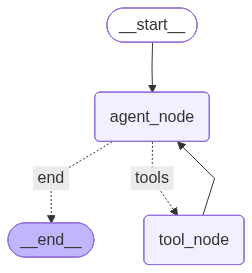

In [14]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
initial_state = {}
result = graph.invoke(initial_state)
result

{'messages': [AIMessage(content=[{'arguments': '{"query":"Add a random vibe to the user\'s query.","vibe":"with a playful neon-glitch energy"}', 'call_id': 'call_lyWnn6GsxshYlWgHVv3vNz2v', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_01faac32acf657f3006a51c357b29c819898238170106ebfbf', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_01faac32acf657f3006a51c35743148198b69ee0867eba7fb6', 'created_at': 1783743319.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_01faac32acf657f3006a51c35743148198b69ee0867eba7fb6', tool_calls=[{'name': 'append_vibes', 'args': {'query': "Add a random vibe to the user's query.", 'vibe': 'with a playful neon-glitch energy'}, 'id': 'call_lyWnn6GsxshYlWgHVv3vNz2v', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 165, 'output_tokens': 37